
Well-sampled substrate design
Method   Param         n         Mean       Median           SD         2.5%        97.5%
------------------------------------------------------------------------
MM       Vmax       1000      10.0384       9.9585       0.9561       8.4315      12.1967
MM       Km         1000      50.8195      49.4445      10.4459      34.3312      74.9083
LB       Vmax       1000      10.3243       9.7401       2.7784       7.1750      16.5202
LB       Km         1000      52.6486      48.8398      19.2435      31.5328      94.5759
EH       Vmax       1000       9.7364       9.7043       0.6371       8.5878      11.0501
EH       Km         1000      47.8643      47.5614       4.8644      39.5474      58.4544
HW       Vmax       1000       9.9489       9.9556       0.8641       8.3563      11.6463
HW       Km         1000      50.1151      50.1363       7.4822      36.7444      64.0624

Undersampled near Km substrate design
Method   Param         n         Mean       Med

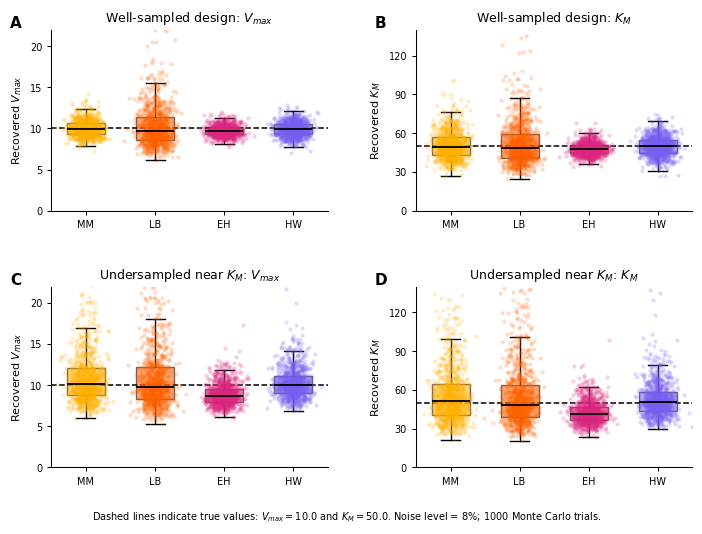

In [ ]:
# ============================================================
# Figure 3: Monte Carlo parameter recovery for Michaelis-Menten
# fitting methods under different substrate sampling strategies
#
# Figure layout:
#   A: Vmax recovery, well-sampled substrate design
#   B: Km recovery, well-sampled substrate design
#   C: Vmax recovery, undersampled-near-Km substrate design
#   D: Km recovery, undersampled-near-Km substrate design
#
# Methods:
#   MM = nonlinear Michaelis-Menten fit
#   LB = Lineweaver-Burk
#   EH = Eadie-Hofstee
#   HW = Hanes-Woolf
#
# Author: J. Mills / ChatGPT-assisted revision
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit
from scipy.stats import linregress
from pathlib import Path

# ------------------------------------------------------------
# USER-ADJUSTABLE SETTINGS
# ------------------------------------------------------------

output_dir = Path("figure_output")
output_dir.mkdir(exist_ok=True)

figure_basename = "figure3_parameter_recovery"

# Reproducibility
random_seed = 42
rng = np.random.default_rng(random_seed)

# True kinetic parameters
Vmax_true = 10.0
Km_true = 50.0

# Sampling strategies
#
# Well-sampled design from the original student prompt:
# spans well below, near, and above Km.
S_good = np.array([2, 5, 10, 20, 40, 60, 80, 120, 200], dtype=float)

# Poor design:
# mostly below Km and does not approach saturation well.
# This makes Vmax harder to constrain and represents a common
# experimental design failure mode.
S_poor = np.array([2, 5, 10, 15, 20, 25, 30, 35, 40], dtype=float)

# Monte Carlo settings
n_trials = 1000
noise_level = 0.08

# Figure size
fig_width = 7.2
fig_height = 5.4

# Font and size settings
FONT_FAMILY = "DejaVu Sans"
BASE_FONT_SIZE = 8
TITLE_FONT_SIZE = 9
LABEL_FONT_SIZE = 8
TICK_FONT_SIZE = 7
LEGEND_FONT_SIZE = 7
PANEL_LABEL_SIZE = 11

# Plot style settings
BOX_WIDTH = 0.55
JITTER_WIDTH = 0.12
POINT_SIZE = 9
POINT_ALPHA = 0.22
BOX_LINEWIDTH = 1.0
MEDIAN_LINEWIDTH = 1.3
REFERENCE_LINEWIDTH = 1.1
AXIS_LINE_WIDTH = 0.75
TICK_WIDTH = 0.75
TICK_LENGTH = 3

# Optional: restrict y-axis limits to keep weird outliers from wrecking the plot.
# Values outside these limits are still included in calculations but may not appear visually.
#
# Set to None if you want automatic scaling.
VMAX_YLIM = (0, 22)
KM_YLIM = (0, 140)

# ------------------------------------------------------------
# IBM COLORBLIND-SAFE PALETTE
# ------------------------------------------------------------

IBM = {
    "gold":    (255/255, 176/255,   0/255),
    "orange":  (254/255,  97/255,   0/255),
    "magenta": (220/255,  38/255, 127/255),
    "purple":  (120/255,  94/255, 240/255),
    "blue":    (100/255, 143/255, 255/255),
    "black":   (0/255,     0/255,   0/255),
}

METHODS = ["MM", "LB", "EH", "HW"]

METHOD_LABELS = {
    "MM": "MM",
    "LB": "LB",
    "EH": "EH",
    "HW": "HW",
}

METHOD_COLORS = {
    "MM": IBM["gold"],
    "LB": IBM["orange"],
    "EH": IBM["magenta"],
    "HW": IBM["purple"],
}

REFERENCE_COLOR = IBM["black"]

# ------------------------------------------------------------
# MATPLOTLIB STYLE
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": BASE_FONT_SIZE,
    "axes.labelsize": LABEL_FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,

    # Keep text editable in Illustrator
    "svg.fonttype": "none",

    # Embed TrueType fonts in PDF/PS
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Math text
    "mathtext.fontset": "dejavusans",

    # General figure settings
    "axes.linewidth": AXIS_LINE_WIDTH,
})

# ------------------------------------------------------------
# MODEL AND FITTING FUNCTIONS
# ------------------------------------------------------------

def michaelis_menten(S, Vmax, Km):
    """Michaelis-Menten equation."""
    return (Vmax * S) / (Km + S)


def generate_noisy_data(S_array, Vmax_true, Km_true, noise_level, rng):
    """
    Generate one noisy Michaelis-Menten data set.

    Noise is proportional to the true velocity:
        sigma_i = noise_level * v_true_i
    """
    v_true = michaelis_menten(S_array, Vmax_true, Km_true)
    noise_std = noise_level * v_true
    v_noisy = v_true + rng.normal(loc=0.0, scale=noise_std)

    # Avoid zero or negative velocities in transformed plots/fits
    v_noisy = np.maximum(v_noisy, 1e-12)

    return v_noisy


def fit_mm_nonlinear(S_array, v_noisy):
    """
    Nonlinear Michaelis-Menten fit using scipy.optimize.curve_fit.
    """
    popt, pcov = curve_fit(
        michaelis_menten,
        S_array,
        v_noisy,
        p0=[np.max(v_noisy), np.median(S_array)],
        bounds=(0, np.inf),
        maxfev=10000
    )

    Vmax_fit, Km_fit = popt
    return Vmax_fit, Km_fit


def fit_lineweaver_burk(S_array, v_noisy):
    """
    Lineweaver-Burk fit:
        1/v = (Km/Vmax)(1/[S]) + 1/Vmax
    """
    x = 1 / S_array
    y = 1 / v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    if intercept == 0:
        raise ValueError("Lineweaver-Burk intercept is zero.")

    Vmax_fit = 1 / intercept
    Km_fit = slope * Vmax_fit

    return Vmax_fit, Km_fit


def fit_eadie_hofstee(S_array, v_noisy):
    """
    Eadie-Hofstee fit:
        v = -Km(v/[S]) + Vmax
    """
    x = v_noisy / S_array
    y = v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    Vmax_fit = intercept
    Km_fit = -slope

    return Vmax_fit, Km_fit


def fit_hanes_woolf(S_array, v_noisy):
    """
    Hanes-Woolf fit:
        [S]/v = (1/Vmax)[S] + Km/Vmax
    """
    x = S_array
    y = S_array / v_noisy

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    if slope == 0:
        raise ValueError("Hanes-Woolf slope is zero.")

    Vmax_fit = 1 / slope
    Km_fit = intercept * Vmax_fit

    return Vmax_fit, Km_fit


def fit_all_methods(S_array, v_noisy):
    """
    Fit one noisy data set using all four methods.
    Returns a dictionary of fitted parameters.
    """
    fits = {}

    # Nonlinear MM
    Vmax_fit, Km_fit = fit_mm_nonlinear(S_array, v_noisy)
    fits["MM"] = {"Vmax": Vmax_fit, "Km": Km_fit}

    # Lineweaver-Burk
    Vmax_fit, Km_fit = fit_lineweaver_burk(S_array, v_noisy)
    fits["LB"] = {"Vmax": Vmax_fit, "Km": Km_fit}

    # Eadie-Hofstee
    Vmax_fit, Km_fit = fit_eadie_hofstee(S_array, v_noisy)
    fits["EH"] = {"Vmax": Vmax_fit, "Km": Km_fit}

    # Hanes-Woolf
    Vmax_fit, Km_fit = fit_hanes_woolf(S_array, v_noisy)
    fits["HW"] = {"Vmax": Vmax_fit, "Km": Km_fit}

    return fits


def run_monte_carlo(S_array, Vmax_true, Km_true, noise_level, n_trials, rng):
    """
    Run Monte Carlo simulation for one substrate sampling strategy.
    """
    results = {
        method: {"Vmax": [], "Km": []}
        for method in METHODS
    }

    failed_fits = {
        method: 0
        for method in METHODS
    }

    for trial in range(n_trials):
        v_noisy = generate_noisy_data(
            S_array=S_array,
            Vmax_true=Vmax_true,
            Km_true=Km_true,
            noise_level=noise_level,
            rng=rng
        )

        for method in METHODS:
            try:
                if method == "MM":
                    Vmax_fit, Km_fit = fit_mm_nonlinear(S_array, v_noisy)
                elif method == "LB":
                    Vmax_fit, Km_fit = fit_lineweaver_burk(S_array, v_noisy)
                elif method == "EH":
                    Vmax_fit, Km_fit = fit_eadie_hofstee(S_array, v_noisy)
                elif method == "HW":
                    Vmax_fit, Km_fit = fit_hanes_woolf(S_array, v_noisy)
                else:
                    raise ValueError(f"Unknown method: {method}")

                # Store only finite results.
                # Negative values are retained because they are meaningful as
                # fitting failures/artifacts of linearized methods.
                if np.isfinite(Vmax_fit) and np.isfinite(Km_fit):
                    results[method]["Vmax"].append(Vmax_fit)
                    results[method]["Km"].append(Km_fit)
                else:
                    failed_fits[method] += 1

            except Exception:
                failed_fits[method] += 1

    # Convert lists to arrays
    for method in METHODS:
        for param in ["Vmax", "Km"]:
            results[method][param] = np.asarray(results[method][param], dtype=float)

    return results, failed_fits


# ------------------------------------------------------------
# SUMMARY FUNCTIONS
# ------------------------------------------------------------

def summarize_results(results, label):
    """
    Print summary statistics for each method and parameter.
    """
    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)
    print(
        f"{'Method':<8} {'Param':<8} "
        f"{'n':>6} {'Mean':>12} {'Median':>12} {'SD':>12} "
        f"{'2.5%':>12} {'97.5%':>12}"
    )
    print("-" * 72)

    for method in METHODS:
        for param in ["Vmax", "Km"]:
            data = results[method][param]
            print(
                f"{method:<8} {param:<8} "
                f"{len(data):6d} "
                f"{np.mean(data):12.4f} "
                f"{np.median(data):12.4f} "
                f"{np.std(data, ddof=1):12.4f} "
                f"{np.percentile(data, 2.5):12.4f} "
                f"{np.percentile(data, 97.5):12.4f}"
            )


# ------------------------------------------------------------
# PLOTTING FUNCTIONS
# ------------------------------------------------------------

def clean_axes(ax):
    """
    Apply consistent publication-style formatting.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=TICK_LENGTH,
        width=TICK_WIDTH
    )

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))


def add_panel_label(ax, label):
    """
    Add bold panel label to upper-left corner.
    """
    ax.text(
        -0.15, 1.08,
        label,
        transform=ax.transAxes,
        fontsize=PANEL_LABEL_SIZE,
        fontweight="bold",
        va="top",
        ha="left"
    )


def plot_parameter_recovery(ax, results, param, true_value, title, ylabel=None, ylim=None):
    """
    Plot boxplots plus jittered points for one parameter.
    """
    positions = np.arange(1, len(METHODS) + 1)

    data_by_method = [results[method][param] for method in METHODS]

    # Boxplot
    box = ax.boxplot(
        data_by_method,
        positions=positions,
        widths=BOX_WIDTH,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(
            color=IBM["black"],
            linewidth=MEDIAN_LINEWIDTH
        ),
        boxprops=dict(
            linewidth=BOX_LINEWIDTH,
            color=IBM["black"]
        ),
        whiskerprops=dict(
            linewidth=BOX_LINEWIDTH,
            color=IBM["black"]
        ),
        capprops=dict(
            linewidth=BOX_LINEWIDTH,
            color=IBM["black"]
        )
    )

    for patch, method in zip(box["boxes"], METHODS):
        patch.set_facecolor(METHOD_COLORS[method])
        patch.set_alpha(0.55)

    # Jittered points
    for i, method in enumerate(METHODS):
        data = results[method][param]
        x_jitter = positions[i] + rng.normal(
            loc=0.0,
            scale=JITTER_WIDTH,
            size=len(data)
        )

        ax.scatter(
            x_jitter,
            data,
            s=POINT_SIZE,
            color=METHOD_COLORS[method],
            alpha=POINT_ALPHA,
            linewidth=0,
            zorder=2
        )

    # Reference line for true value
    ax.axhline(
        true_value,
        color=REFERENCE_COLOR,
        linestyle="--",
        linewidth=REFERENCE_LINEWIDTH,
        zorder=1
    )

    ax.set_title(title)
    ax.set_xticks(positions)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS])

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    clean_axes(ax)


# ------------------------------------------------------------
# RUN MONTE CARLO SIMULATIONS
# ------------------------------------------------------------

results_good, failed_good = run_monte_carlo(
    S_array=S_good,
    Vmax_true=Vmax_true,
    Km_true=Km_true,
    noise_level=noise_level,
    n_trials=n_trials,
    rng=rng
)

results_poor, failed_poor = run_monte_carlo(
    S_array=S_poor,
    Vmax_true=Vmax_true,
    Km_true=Km_true,
    noise_level=noise_level,
    n_trials=n_trials,
    rng=rng
)

# Print summary tables
summarize_results(
    results_good,
    label="Well-sampled substrate design"
)

summarize_results(
    results_poor,
    label="Undersampled near Km substrate design"
)

print("\nFailed fits:")
print("Well-sampled:", failed_good)
print("Undersampled:", failed_poor)

# ------------------------------------------------------------
# MAKE FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(fig_width, fig_height),
    constrained_layout=False
)

# Top row: well-sampled design
plot_parameter_recovery(
    ax=axes[0, 0],
    results=results_good,
    param="Vmax",
    true_value=Vmax_true,
    title=r"Well-sampled design: $V_{max}$",
    ylabel=r"Recovered $V_{max}$",
    ylim=VMAX_YLIM
)
add_panel_label(axes[0, 0], "A")

plot_parameter_recovery(
    ax=axes[0, 1],
    results=results_good,
    param="Km",
    true_value=Km_true,
    title=r"Well-sampled design: $K_M$",
    ylabel=r"Recovered $K_M$",
    ylim=KM_YLIM
)
add_panel_label(axes[0, 1], "B")

# Bottom row: undersampled near Km
plot_parameter_recovery(
    ax=axes[1, 0],
    results=results_poor,
    param="Vmax",
    true_value=Vmax_true,
    title=r"Undersampled near $K_M$: $V_{max}$",
    ylabel=r"Recovered $V_{max}$",
    ylim=VMAX_YLIM
)
add_panel_label(axes[1, 0], "C")

plot_parameter_recovery(
    ax=axes[1, 1],
    results=results_poor,
    param="Km",
    true_value=Km_true,
    title=r"Undersampled near $K_M$: $K_M$",
    ylabel=r"Recovered $K_M$",
    ylim=KM_YLIM
)
add_panel_label(axes[1, 1], "D")

# Optional explanatory note
fig.text(
    0.5,
    0.015,
    rf"Dashed lines indicate true values: $V_{{max}}={Vmax_true:.1f}$ and $K_M={Km_true:.1f}$. "
    rf"Noise level = {noise_level:.0%}; {n_trials} Monte Carlo trials.",
    ha="center",
    va="bottom",
    fontsize=7
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.12,
    top=0.93,
    wspace=0.32,
    hspace=0.42
)

# ------------------------------------------------------------
# EXPORT
# ------------------------------------------------------------

fig.savefig(output_dir / f"{figure_basename}.svg", bbox_inches="tight")
fig.savefig(output_dir / f"{figure_basename}.pdf", bbox_inches="tight")
fig.savefig(output_dir / f"{figure_basename}.png", dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
# ============================================================
# Table 2 summary statistics from Figure 3 Monte Carlo results
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Number of decimal places for table output
PARAM_DECIMALS = 3
BIAS_DECIMALS = 2
CI_DECIMALS = 3

# Choose whether to include standard deviation in the main table
INCLUDE_STD = True

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def summarize_parameter(data, true_value):
    """
    Calculate summary statistics for one recovered parameter distribution.

    Parameters
    ----------
    data : array-like
        Recovered parameter values from Monte Carlo simulations.
    true_value : float
        True value used to generate the simulated data.

    Returns
    -------
    dict
        Summary statistics.
    """
    data = np.asarray(data, dtype=float)

    # Keep only finite values
    finite_data = data[np.isfinite(data)]

    n_valid = len(finite_data)

    if n_valid == 0:
        return {
            "n_valid": 0,
            "mean": np.nan,
            "std": np.nan,
            "bias_percent": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
        }

    mean_val = np.mean(finite_data)
    std_val = np.std(finite_data, ddof=1) if n_valid > 1 else np.nan

    bias_percent = 100 * (mean_val - true_value) / true_value

    ci_lower, ci_upper = np.percentile(finite_data, [2.5, 97.5])

    return {
        "n_valid": n_valid,
        "mean": mean_val,
        "std": std_val,
        "bias_percent": bias_percent,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
    }


def make_table2_summary(results, failed_fits, sampling_label):
    """
    Build a summary table for one sampling design.

    Parameters
    ----------
    results : dict
        Monte Carlo results dictionary.
        Expected format:
            results[method]["Vmax"]
            results[method]["Km"]

    failed_fits : dict
        Dictionary of failed fits by method.
        Expected format:
            failed_fits[method] = number of failed fits

    sampling_label : str
        Label for the sampling design.

    Returns
    -------
    list of dict
        Rows for a pandas DataFrame.
    """
    rows = []

    method_full_names = {
        "MM": "Nonlinear MM",
        "LB": "Lineweaver–Burk",
        "EH": "Eadie–Hofstee",
        "HW": "Hanes–Woolf",
    }

    for method in METHODS:

        vmax_summary = summarize_parameter(
            results[method]["Vmax"],
            true_value=Vmax_true
        )

        km_summary = summarize_parameter(
            results[method]["Km"],
            true_value=Km_true
        )

        row = {
            "Sampling design": sampling_label,
            "Method": method_full_names.get(method, method),

            "Mean Vmax": vmax_summary["mean"],
            "SD Vmax": vmax_summary["std"],
            "Vmax bias (%)": vmax_summary["bias_percent"],
            "Vmax 95% interval": (
                vmax_summary["ci_lower"],
                vmax_summary["ci_upper"]
            ),

            "Mean KM": km_summary["mean"],
            "SD KM": km_summary["std"],
            "KM bias (%)": km_summary["bias_percent"],
            "KM 95% interval": (
                km_summary["ci_lower"],
                km_summary["ci_upper"]
            ),

            "Valid fits": min(vmax_summary["n_valid"], km_summary["n_valid"]),
            "Failed fits": failed_fits.get(method, 0),
        }

        rows.append(row)

    return rows


def format_interval(interval, decimals=3):
    """
    Format a confidence/percentile interval for display.
    """
    lo, hi = interval

    if np.isnan(lo) or np.isnan(hi):
        return "—"

    return f"{lo:.{decimals}f}–{hi:.{decimals}f}"


# ------------------------------------------------------------
# BUILD SUMMARY TABLE
# ------------------------------------------------------------

rows = []

rows.extend(
    make_table2_summary(
        results=results_good,
        failed_fits=failed_good,
        sampling_label="Well-sampled"
    )
)

rows.extend(
    make_table2_summary(
        results=results_poor,
        failed_fits=failed_poor,
        sampling_label="Undersampled near KM"
    )
)

table2_raw = pd.DataFrame(rows)

# ------------------------------------------------------------
# FORMAT FOR WORD / MANUSCRIPT
# ------------------------------------------------------------

table2_formatted = table2_raw.copy()

table2_formatted["Mean Vmax"] = table2_formatted["Mean Vmax"].map(
    lambda x: f"{x:.{PARAM_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["SD Vmax"] = table2_formatted["SD Vmax"].map(
    lambda x: f"{x:.{PARAM_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["Vmax bias (%)"] = table2_formatted["Vmax bias (%)"].map(
    lambda x: f"{x:.{BIAS_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["Vmax 95% interval"] = table2_formatted["Vmax 95% interval"].map(
    lambda x: format_interval(x, decimals=CI_DECIMALS)
)

table2_formatted["Mean KM"] = table2_formatted["Mean KM"].map(
    lambda x: f"{x:.{PARAM_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["SD KM"] = table2_formatted["SD KM"].map(
    lambda x: f"{x:.{PARAM_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["KM bias (%)"] = table2_formatted["KM bias (%)"].map(
    lambda x: f"{x:.{BIAS_DECIMALS}f}" if np.isfinite(x) else "—"
)

table2_formatted["KM 95% interval"] = table2_formatted["KM 95% interval"].map(
    lambda x: format_interval(x, decimals=CI_DECIMALS)
)

# Optional compact version for main manuscript
if INCLUDE_STD:
    table2_for_word = table2_formatted[
        [
            "Sampling design",
            "Method",
            "Mean Vmax",
            "SD Vmax",
            "Vmax bias (%)",
            "Vmax 95% interval",
            "Mean KM",
            "SD KM",
            "KM bias (%)",
            "KM 95% interval",
            "Failed fits",
        ]
    ]
else:
    table2_for_word = table2_formatted[
        [
            "Sampling design",
            "Method",
            "Mean Vmax",
            "Vmax bias (%)",
            "Vmax 95% interval",
            "Mean KM",
            "KM bias (%)",
            "KM 95% interval",
            "Failed fits",
        ]
    ]

# Display in Colab
display(table2_for_word)

# Save files for copy/paste or import into Word
table2_raw.to_csv("table2_parameter_recovery_raw.csv", index=False)
table2_for_word.to_csv("table2_parameter_recovery_formatted.csv", index=False)

# Print markdown table for easy copy/paste
print("\nMarkdown table:")
print(table2_for_word.to_markdown(index=False))

,Sampling design,Method,Mean Vmax,SD Vmax,Vmax bias (%),Vmax 95% interval,Mean KM,SD KM,KM bias (%),KM 95% interval,Failed fits
0,Well-sampled,Nonlinear MM,10.038,0.956,0.38,8.432–12.197,50.820,10.446,1.64,34.331–74.908,0
1,Well-sampled,Lineweaver–Burk,10.324,2.778,3.24,7.175–16.520,52.649,19.243,5.30,31.533–94.576,0
2,Well-sampled,Eadie–Hofstee,9.736,0.637,-2.64,8.588–11.050,47.864,4.864,-4.27,39.547–58.454,0
3,Well-sampled,Hanes–Woolf,9.949,0.864,-0.51,8.356–11.646,50.115,7.482,0.23,36.744–64.062,0
4,Undersampled near KM,Nonlinear MM,10.989,3.862,9.89,7.087–20.016,57.409,28.665,14.82,28.878–121.816,0
5,Undersampled near KM,Lineweaver–Burk,24.396,422.442,143.96,6.392–23.393,144.834,2774.456,189.67,27.767–136.524,0
6,Undersampled near KM,Eadie–Hofstee,8.891,1.303,-11.09,6.917–12.042,42.475,8.664,-15.05,29.280–62.185,0
7,Undersampled near KM,Hanes–Woolf,10.298,1.874,2.98,7.612–14.661,52.431,12.771,4.86,34.092–83.861,0



Markdown table:
| Sampling design      | Method          |   Mean Vmax |   SD Vmax |   Vmax bias (%) | Vmax 95% interval   |   Mean KM |    SD KM |   KM bias (%) | KM 95% interval   |   Failed fits |
|:---------------------|:----------------|------------:|----------:|----------------:|:--------------------|----------:|---------:|--------------:|:------------------|--------------:|
| Well-sampled         | Nonlinear MM    |      10.038 |     0.956 |            0.38 | 8.432–12.197        |    50.82  |   10.446 |          1.64 | 34.331–74.908     |             0 |
| Well-sampled         | Lineweaver–Burk |      10.324 |     2.778 |            3.24 | 7.175–16.520        |    52.649 |   19.243 |          5.3  | 31.533–94.576     |             0 |
| Well-sampled         | Eadie–Hofstee   |       9.736 |     0.637 |           -2.64 | 8.588–11.050        |    47.864 |    4.864 |         -4.27 | 39.547–58.454     |             0 |
| Well-sampled         | Hanes–Woolf     |       9.949 |     0.